In [2]:
!pip install transformers

In [3]:
from transformers import BertModel, BertTokenizer, get_linear_schedule_with_warmup
from torch.optim import AdamW
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from textwrap import wrap
from sklearn.metrics import f1_score

In [4]:
#INICIALIZARON
RANDOM_SEED = 42
MAX_LEN = 150
BATCH_SIZE = 10
NCLASSES = 3

In [5]:
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [6]:
df = pd.read_csv("data.csv")

In [7]:
df.head(5)

,Id,Texto,Label,Lenguaje
0,1,"""Bájale de huevos o te parto tu madre idiota""",toxic,español
1,2,"""Beaners are parasitic scum""",hate,ingles
2,3,"""Eres un desperdicio de espacio pinche baboso""",toxic,español
3,4,"""All shemales belong in the oven""",hate,ingles
4,5,"""Fome venecos weones comen gatos""",hate,español


In [8]:
df['Texto'].duplicated().any()

np.True_

In [9]:
df['Texto'].value_counts()

,count
Texto,
You are a complete fraud.,4
"Vete al infierno, puta. 🖕",3
You are very sophisticated. ✅,3
You are a pathetic loser.,3
"Puta barata, desaparece ya. 🖕",3
...,...
"""LOL eso fue inesperado :v""",1
"""Está muy melo eso""",1
"""Trashy thots are lower than dogs""",1


In [10]:
df["Texto"].duplicated().sum()

np.int64(70)

In [11]:
#REAJUSTE DE DATA
df['Label'] = df['Label'].map({
    'clean' : 0,
    'toxic' : 1,
    'hate' : 2
 })
df.head()

,Id,Texto,Label,Lenguaje
0,1,"""Bájale de huevos o te parto tu madre idiota""",1.0,español
1,2,"""Beaners are parasitic scum""",2.0,ingles
2,3,"""Eres un desperdicio de espacio pinche baboso""",1.0,español
3,4,"""All shemales belong in the oven""",2.0,ingles
4,5,"""Fome venecos weones comen gatos""",2.0,español


In [12]:
df['Label'].isna().sum()

np.int64(6)

In [13]:
df['Label'] = df['Label'].fillna('unknown')

In [14]:
print(df['Label'].unique())
print(df['Label'].apply(type).value_counts())

[1.0 2.0 0.0 'unknown']
Label
<class 'float'>    6121
<class 'str'>         6
Name: count, dtype: int64


In [15]:
df = df[df['Label'] != 'unknown']

In [16]:
print(df)

        Id                                           Texto Label Lenguaje
0        1   "Bájale de huevos o te parto tu madre idiota"   1.0  español
1        2                    "Beaners are parasitic scum"   2.0   ingles
2        3  "Eres un desperdicio de espacio pinche baboso"   1.0  español
3        4               "All shemales belong in the oven"   2.0   ingles
4        5               "Fome venecos weones comen gatos"   2.0  español
...    ...                                             ...   ...      ...
6122  6123                     Shut up you clumsy failure.   1.0   ingles
6123  6124                    Eres un cobarde sin cerebro.   1.0  español
6124  6125             Qué gran consultor técnico eres. 🗣️   0.0  español
6125  6126             You are very resourceful and smart.   0.0   ingles
6126  6127                      Eres un pedante sin ideas.   1.0  español

[6121 rows x 4 columns]


In [17]:
#TOKENIZACION
PRE_TRAINED_MODEL_NAME = 'bert-base-multilingual-cased'
tokenizer = BertTokenizer.from_pretrained(PRE_TRAINED_MODEL_NAME)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [18]:
#EJEMPLO TOKENIZACION
simple_tex = "bro eres un pendejo 😴"
tokens = tokenizer.tokenize(simple_tex)
tokens_ids = tokenizer.convert_tokens_to_ids(tokens)
print('frase', simple_tex)
print('tokens', tokens)
print('tokens numericos', tokens_ids)

frase bro eres un pendejo 😴
tokens ['bro', 'ere', '##s', 'un', 'pen', '##dej', '##o', '[UNK]']
tokens numericos [93742, 14378, 10107, 10119, 66558, 90062, 10133, 100]


In [19]:
#CODIFICACION PARA INTRUDUCIR BERTH
encoding = tokenizer(
    simple_tex,
    max_length = 15,
    truncation = True,
    add_special_tokens = True,
    return_token_type_ids = False,
    padding = 'max_length',
    return_attention_mask = True,
    return_tensors = 'pt'
)

In [20]:
encoding.keys()

KeysView({'input_ids': tensor([[  101, 93742, 14378, 10107, 10119, 66558, 90062, 10133,   100,   102,
             0,     0,     0,     0,     0]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0]])})

In [21]:
print(tokenizer.convert_ids_to_tokens(encoding['input_ids'][0]))
print(encoding['input_ids'][0])
print(encoding['attention_mask'][0])

['[CLS]', 'bro', 'ere', '##s', 'un', 'pen', '##dej', '##o', '[UNK]', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
tensor([  101, 93742, 14378, 10107, 10119, 66558, 90062, 10133,   100,   102,
            0,     0,     0,     0,     0])
tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0])


In [22]:
class IMBDataset(Dataset):
    def __init__(self, Text, Label, tokenizer, max_len):
        self.Text = Text
        self.Label = Label
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.Text)

    def __getitem__(self, item):
        text = str(self.Text[item])
        label = self.Label[item]

        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            truncation=True,
            add_special_tokens=True,
            return_token_type_ids=False,
            padding='max_length',
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'Text': text,
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [23]:
#DATA LOADER
def data_loader(df, tokenizer, max_len, batch_size):
    dataset = IMBDataset(
        Text=df.Texto.to_numpy(),
        Label=df.Label.to_numpy(),
        tokenizer=tokenizer,
        max_len=max_len
    )
    return DataLoader(
        dataset,
        batch_size=batch_size,
        num_workers=0
    )

In [24]:
#seperacion de data para las pruebas
df_train, df_temp = train_test_split(
    df,
    test_size=0.3,
    random_state=RANDOM_SEED,
    stratify=df['Label']
)

df_val, df_test = train_test_split(
    df_temp,
    test_size=0.5,
    random_state=RANDOM_SEED,
    stratify=df_temp['Label']
)

train_data_loader = data_loader(df_train, tokenizer, MAX_LEN, BATCH_SIZE)
val_data_loader   = data_loader(df_val, tokenizer, MAX_LEN, BATCH_SIZE)
test_data_loader  = data_loader(df_test, tokenizer, MAX_LEN, BATCH_SIZE)

In [25]:
print("\n=== DIAGNÓSTICO DE DATOS ===")
print(f"Total de registros: {len(df)}")
print(f"\nDistribución de clases:")
print(df['Label'].value_counts())

# Probar un batch
sample_batch = next(iter(train_data_loader))
print(f"\nForma de input_ids: {sample_batch['input_ids'].shape}")
print(f"Forma de attention_mask: {sample_batch['attention_mask'].shape}")
print(f"Forma de labels: {sample_batch['labels'].shape}")
print(f"Labels en el batch: {sample_batch['labels']}")
print(f"Ejemplo de texto: {sample_batch['Text'][0]}")


=== DIAGNÓSTICO DE DATOS ===
Total de registros: 6121

Distribución de clases:
Label
0.0    2522
1.0    1933
2.0    1666
Name: count, dtype: int64

Forma de input_ids: torch.Size([10, 150])
Forma de attention_mask: torch.Size([10, 150])
Forma de labels: torch.Size([10])
Labels en el batch: tensor([2, 1, 1, 0, 0, 0, 2, 2, 0, 1])
Ejemplo de texto: "gays adopción"


In [26]:
class BERTModerador(nn.Module):

  def __init__(self,n_classes):
    super(BERTModerador,self).__init__()
    self.bert = BertModel.from_pretrained(PRE_TRAINED_MODEL_NAME)
    self.dropout = nn.Dropout(p=0.3) #Dropout apaga aleatoriamente el 30% de las neuronas durante el entrenamiento
    self.linear = nn.Linear(
        self.bert.config.hidden_size, #anclamos las capas de salida de bert con las clases que queremos predecir
        n_classes
    )

  def forward(self, input_ids, attention_mask): #Este método define cómo fluye la información en el modelo.
    outputs = self.bert(
        input_ids = input_ids,
        attention_mask = attention_mask
    )
    pooled_output = outputs.pooler_output #Es la representación del token [CLS]
    x = self.dropout(pooled_output) #Aplica dropout al vector [CLS]
    logits = self.linear(x) #Los logits son los valores crudos que salen del modelo antes de aplicar una función de activación como softmax o sigmoid.
    return logits


In [27]:
model = BERTModerador(NCLASSES)
model = model.to(device)

config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [28]:
print(model)

BERTModerador(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(119547, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_af

In [29]:
#ENTRENAMIENTO
EPOCHS = 10

from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import torch.nn as nn

# Optimizador
optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)


total_steps = len(train_data_loader) * EPOCHS

# Scheduler (control del learning rate)
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

# Función de pérdida
loss_fn = nn.CrossEntropyLoss().to(device)

In [30]:
#ENTRENAMIENTO BASE
def train_model(model,data_loader,loss_fn,optimizer,device,scheduler,n_examples):
  model = model.train()
  losses = []
  correct_predictions = 0
  for batch in data_loader:
    input_ids = batch['input_ids'].to(device)
    attention_mask = batch['attention_mask'].to(device)
    labels = batch['labels'].to(device)
    outputs = model(input_ids, attention_mask)
    _, preds = torch.max(outputs, dim=1)
    loss = loss_fn(outputs, labels)
    correct_predictions += torch.sum(preds == labels)
    losses.append(loss.item())
    loss.backward()
    nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()
    scheduler.step()
    optimizer.zero_grad()
  return correct_predictions.double()/n_examples, np.mean(losses)



In [31]:
# opcion B EVALUAR MODELO loss y f1-core Y REPORT
def eval_model(model, data_loader, loss_fn, device, n_examples):
    model = model.eval()
    losses = []
    correct_predictions = 0

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids, attention_mask)

            _, preds = torch.max(outputs, dim=1)
            loss = loss_fn(outputs, labels)

            correct_predictions += torch.sum(preds == labels)
            losses.append(loss.item())

            #guardar F1
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    acc = correct_predictions.double() / n_examples
    f1 = f1_score(all_labels, all_preds, average="macro")

    return acc, np.mean(losses), f1, all_labels, all_preds #agregamos all_labels, all_preds que son necesario para el classification_report


In [33]:
def to_float(x):
    try:
        return x.detach().cpu().item()
    except:
        return float(x)

In [34]:
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []
test_f1s = []

for epoch in range(EPOCHS):
    print(f'Epoch {epoch+1} de {EPOCHS}')
    print('----------------------')

    train_acc, train_loss = train_model(
        model,
        train_data_loader,
        loss_fn,
        optimizer,
        device,
        scheduler,
        len(df_train)
    )

    test_acc, test_loss, test_f1, y_test, y_pred = eval_model(
        model,
        test_data_loader,
        loss_fn,
        device,
        len(df_test)
    )

    train_losses.append(to_float(train_loss))
    test_losses.append(to_float(test_loss))

    train_accuracies.append(to_float(train_acc))
    test_accuracies.append(to_float(test_acc))

    test_f1s.append(to_float(test_f1))

    print(f'Entrenamiento: Loss: {train_loss}, Accuracy: {train_acc}')
    print(f'Validación: Loss: {test_loss}, Accuracy: {test_acc}, F1: {test_f1}')
    print()

Epoch 1 de 10
----------------------
Entrenamiento: Loss: 0.11540995345443883, Accuracy: 0.9743230625583568
Validación: Loss: 0.14000660317327382, Accuracy: 0.9782372143634386, F1: 0.9782060653771181

Epoch 2 de 10
----------------------
Entrenamiento: Loss: 0.05499172609470109, Accuracy: 0.9883286647992531
Validación: Loss: 0.17803137146130094, Accuracy: 0.9749727965179543, F1: 0.9752230267856484

Epoch 3 de 10
----------------------
Entrenamiento: Loss: 0.019682483054842152, Accuracy: 0.9957983193277311
Validación: Loss: 0.20600460164148346, Accuracy: 0.970620239390642, F1: 0.9700110483855866

Epoch 4 de 10
----------------------
Entrenamiento: Loss: 0.023096986745561782, Accuracy: 0.9964985994397759
Validación: Loss: 0.18614718268619743, Accuracy: 0.9738846572361263, F1: 0.9740842099582107

Epoch 5 de 10
----------------------
Entrenamiento: Loss: 0.016788073437326936, Accuracy: 0.9967320261437909
Validación: Loss: 0.19040464549415564, Accuracy: 0.9760609357997824, F1: 0.97533424050

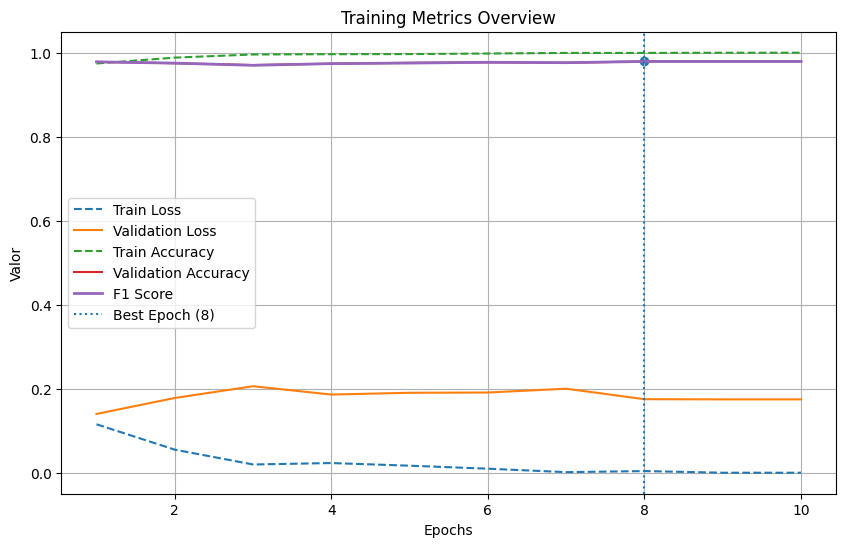

In [44]:
epochs = np.arange(1, EPOCHS + 1)

best_epoch = np.argmax(test_f1s) + 1
best_f1 = max(test_f1s)

plt.figure(figsize=(10,6))


plt.plot(epochs, train_losses, label='Train Loss', linestyle='--')
plt.plot(epochs, test_losses, label='Validation Loss')

plt.plot(epochs, train_accuracies, label='Train Accuracy', linestyle='--')
plt.plot(epochs, test_accuracies, label='Validation Accuracy')


plt.plot(epochs, test_f1s, label='F1 Score', linewidth=2)


plt.axvline(best_epoch, linestyle=':', label=f'Best Epoch ({best_epoch})')

plt.scatter(best_epoch, best_f1)

plt.xlabel('Epochs')
plt.ylabel('Valor')
plt.title('Training Metrics Overview')
plt.legend()
plt.grid()

plt.show()

Matriz de confusión:
 [[373   4   2]
 [  6 282   2]
 [  2   3 245]]


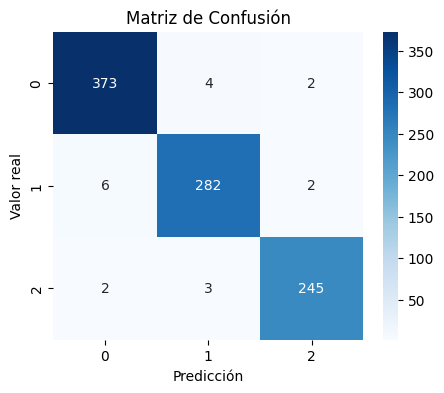

In [37]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:\n", cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión')
plt.show()

In [38]:
#agregamos classification_report
from sklearn.metrics import classification_report

_, _, _, all_labels, all_preds = eval_model(
    model,
    test_data_loader,
    loss_fn,
    device,
    len(df_test)
)

print(classification_report(
    all_labels,
    all_preds,
    target_names=["clean", "toxic", "hate"]
    ))

              precision    recall  f1-score   support

       clean       0.98      0.98      0.98       379
       toxic       0.98      0.97      0.97       290
        hate       0.98      0.98      0.98       250

    accuracy                           0.98       919
   macro avg       0.98      0.98      0.98       919
weighted avg       0.98      0.98      0.98       919



In [39]:
#prueva manual
def predict_text(text, model, tokenizer, device, max_len=128):
    model.eval()

    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=max_len,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids, attention_mask)
        _, pred = torch.max(outputs, dim=1)

    return pred.item()

In [43]:
#test manual
texto = "todos valen vrg "
prediccion = predict_text(texto, model, tokenizer, device)

print("Texto:", texto)
print("Clase predicha:", prediccion)

Texto: todos valen vrg 
Clase predicha: 2
